# Notebook 06 — Test Time Augmentation (TTA)

**Project:** Multimodal skin cancer detection — HAM10000  
**Author:** Maialen Blanco Ibarra  
**Date:** March 2026

---

This notebook evaluates the effect of **Test Time Augmentation (TTA)** on the final model **E09** (Color Constancy + age + localization, seed=42).

Instead of a single forward pass per image, TTA runs **N augmented versions** of each image through the model and **averages the predicted probabilities**. This produces more robust predictions without any retraining.

**Why TTA helps:**  
A dermoscopic lesion can appear at any orientation. If the model assigns a borderline probability (e.g. 0.45 for melanoma), averaging over multiple orientations can push the prediction above the decision threshold, improving recall for difficult classes.

**Structure:**
1. Setup & model loading
2. TTA transforms definition
3. TTA evaluation loop
4. Metrics comparison — E09 baseline vs E09 + TTA
5. Per-class analysis
6. Save TTA probabilities
7. Conclusions

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    f1_score, recall_score, precision_score,
    roc_auc_score, average_precision_score
)
from sklearn.preprocessing import label_binarize
from tqdm import tqdm

# Project root
sys.path.append('../')
from src.config import CLASSES, NUM_CLASSES
from src.model import SkinLesionModel
from src.dataset import SkinLesionDataset

# ── Paths ──────────────────────────────────────────────────────────────────
SPLITS_DIR  = '../data/splits/'
MODELS_DIR  = '../outputs/models/'
PROBS_DIR   = '../outputs/probs/'
FIGURES_DIR = '../outputs/figures/'
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(PROBS_DIR,   exist_ok=True)

# ── Model config — E09 ─────────────────────────────────────────────────────
EXPERIMENT   = 'prep_colorconstancy__meta_age+localization__seed_42'
METADATA     = ['age', 'localization']
PREPROCESS   = 'colorconstancy'
WEIGHTS_PATH = os.path.join(MODELS_DIR, EXPERIMENT + '_best.pth')

# ── Device ─────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'Classes: {CLASSES}')
print(f'Weights: {WEIGHTS_PATH}')
print(f'Weights exist: {os.path.exists(WEIGHTS_PATH)}')

/home/maialen/pfg-venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Weights: ../outputs/models/prep_colorconstancy__meta_age+localization__seed_42_best.pth
Weights exist: True


In [2]:
# ── Load E09 model ─────────────────────────────────────────────────────────
metadata_dim = 16  # age=1, localization=15

model = SkinLesionModel(metadata_dim=metadata_dim)
model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=DEVICE, weights_only=True))
model.to(DEVICE)
model.eval()

print(f'Model loaded successfully.')
print(f'Metadata dim: {metadata_dim}')
print(f'  → age:          1')
print(f'  → localization: 15')
print(f'  → total:        {metadata_dim}')

Model loaded successfully.
Metadata dim: 16
  → age:          1
  → localization: 15
  → total:        16


---
## Section 2: TTA Transforms Definition

6 transforms are defined, all geometrically valid for dermoscopic images.
Color-based transforms (brightness, contrast) are deliberately excluded —
the Color Constancy preprocessing has already normalized illumination variability.

| # | Transform           |
|---|---------------------|
| 0 | Original (no augmentation) |
| 1 | Horizontal flip     |
| 2 | Vertical flip       |
| 3 | Horizontal + Vertical flip |
| 4 | 90° rotation        |
| 5 | 270° rotation       |

In [3]:
# ImageNet normalization — same as val/test in src/transforms.py
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def get_tta_transforms():
    """
    Returns a list of 6 TTA transforms.
    All are geometric — no color/brightness changes.
    Each transform includes resize + toTensor + normalize.
    """
    base = [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ]

    tta_list = [
        # 0 — Original
        transforms.Compose(base),
        # 1 — Horizontal flip
        transforms.Compose([transforms.Resize((224, 224)),
                            transforms.RandomHorizontalFlip(p=1.0),
                            transforms.ToTensor(),
                            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
        # 2 — Vertical flip
        transforms.Compose([transforms.Resize((224, 224)),
                            transforms.RandomVerticalFlip(p=1.0),
                            transforms.ToTensor(),
                            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
        # 3 — Horizontal + Vertical flip
        transforms.Compose([transforms.Resize((224, 224)),
                            transforms.RandomHorizontalFlip(p=1.0),
                            transforms.RandomVerticalFlip(p=1.0),
                            transforms.ToTensor(),
                            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
        # 4 — 90° rotation
        transforms.Compose([transforms.Resize((224, 224)),
                            transforms.RandomRotation((90, 90)),
                            transforms.ToTensor(),
                            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
        # 5 — 270° rotation
        transforms.Compose([transforms.Resize((224, 224)),
                            transforms.RandomRotation((270, 270)),
                            transforms.ToTensor(),
                            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    ]
    return tta_list

TTA_TRANSFORMS = get_tta_transforms()
print(f'Number of TTA transforms: {len(TTA_TRANSFORMS)}')
for i, t in enumerate(TTA_TRANSFORMS):
    print(f'  Transform {i}: {[type(tr).__name__ for tr in t.transforms]}')

Number of TTA transforms: 6
  Transform 0: ['Resize', 'ToTensor', 'Normalize']
  Transform 1: ['Resize', 'RandomHorizontalFlip', 'ToTensor', 'Normalize']
  Transform 2: ['Resize', 'RandomVerticalFlip', 'ToTensor', 'Normalize']
  Transform 3: ['Resize', 'RandomHorizontalFlip', 'RandomVerticalFlip', 'ToTensor', 'Normalize']
  Transform 4: ['Resize', 'RandomRotation', 'ToTensor', 'Normalize']
  Transform 5: ['Resize', 'RandomRotation', 'ToTensor', 'Normalize']


---
## Section 3: TTA Evaluation Loop

For each image in the test set:
1. Apply each of the 6 transforms independently
2. Run a forward pass through E09 for each transformed version
3. Average the 6 softmax probability vectors
4. Use the averaged probabilities as the final prediction

In [13]:
from src.dataset import find_image_path as find_img

def evaluate_tta(model, test_df, tta_transforms, device, metadata=METADATA, preprocess=PREPROCESS):
    """
    Runs TTA evaluation over the test set.
    Returns averaged probabilities (n_samples, 7) and true labels (n_samples,).
    """
    # Build dataset to reuse _get_metadata
    dataset = SkinLesionDataset(
        df         = test_df,
        metadata   = metadata,
        preprocess = preprocess
    )

    model.eval()
    all_probs  = []
    all_labels = []

    with torch.no_grad():
        for idx, row in tqdm(test_df.iterrows(), total=len(test_df), desc='TTA evaluation'):

            # ── Load image ─────────────────────────────────────────────────
            img_path, already_preprocessed = find_img(row['image_id'], preprocess)
            image = Image.open(img_path).convert('RGB')

            # ── Metadata vector ────────────────────────────────────────────
            meta_vector = dataset._get_metadata(row)
            meta_tensor = torch.tensor(meta_vector, dtype=torch.float32).unsqueeze(0).to(device)

            # ── TTA: 6 forward passes ──────────────────────────────────────
            probs_list = []
            for transform in tta_transforms:
                img_tensor = transform(image).unsqueeze(0).to(device)
                logits     = model(img_tensor, meta_tensor)
                probs      = F.softmax(logits, dim=1).cpu().numpy()[0]
                probs_list.append(probs)

            # ── Average probabilities ──────────────────────────────────────
            avg_probs = np.mean(probs_list, axis=0)
            all_probs.append(avg_probs)
            all_labels.append(CLASSES.index(row['dx']))

    return np.array(all_probs), np.array(all_labels)


# ── Load test split ────────────────────────────────────────────────────────
test_df = pd.read_csv(os.path.join(SPLITS_DIR, 'test.csv'))
print(f'Test set size: {len(test_df)} images')
print(f'Class mapping: { {c: i for i, c in enumerate(CLASSES)} }')

Test set size: 1503 images
Class mapping: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


In [14]:
print('Running TTA evaluation on E09 (6 transforms × 1503 images)...')

tta_probs, tta_labels = evaluate_tta(
    model          = model,
    test_df        = test_df,
    tta_transforms = TTA_TRANSFORMS,
    device         = DEVICE
)

print(f'\nDone.')
print(f'TTA probs shape:  {tta_probs.shape}')
print(f'TTA labels shape: {tta_labels.shape}')
print(f'Unique labels:    {np.unique(tta_labels)}')
print(f'Label counts:     {np.bincount(tta_labels)}')

Running TTA evaluation on E09 (6 transforms × 1503 images)...


TTA evaluation: 100%|██████████| 1503/1503 [01:11<00:00, 21.11it/s]


Done.
TTA probs shape:  (1503, 7)
TTA labels shape: (1503,)
Unique labels:    [0 1 2 3 4 5 6]
Label counts:     [  49   77  165   17  167 1006   22]


---
## Section 4: Metrics Comparison — E09 Baseline vs E09 + TTA

The baseline probabilities (no TTA) are loaded from the `.npy` files generated
during the original E09 evaluation. Both are compared on the same test set (n=1503).

In [15]:
# ── Load baseline E09 probabilities (no TTA) ──────────────────────────────
baseline_probs  = np.load(os.path.join(PROBS_DIR, EXPERIMENT + '_probs.npy'))
baseline_labels = np.load(os.path.join(PROBS_DIR, EXPERIMENT + '_labels.npy'))

def compute_metrics(probs, labels):
    """Computes key metrics from probability arrays."""
    preds       = np.argmax(probs, axis=1)
    labels_bin  = label_binarize(labels, classes=list(range(NUM_CLASSES)))

    macro_f1       = f1_score(labels, preds, average='macro', zero_division=0)
    macro_recall   = recall_score(labels, preds, average='macro', zero_division=0)
    macro_prec     = precision_score(labels, preds, average='macro', zero_division=0)
    roc_auc        = roc_auc_score(labels, probs, multi_class='ovr', average='macro')
    map_score      = np.mean([average_precision_score(labels_bin[:, c], probs[:, c])
                               for c in range(NUM_CLASSES)])
    mel_idx        = CLASSES.index('mel')
    mel_recall     = recall_score(labels == mel_idx, preds == mel_idx,
                                  average='binary', zero_division=0)

    return {
        'Macro F1':        round(macro_f1,     4),
        'Macro Recall':    round(macro_recall,  4),
        'Macro Precision': round(macro_prec,    4),
        'ROC-AUC':         round(roc_auc,       4),
        'mAP':             round(map_score,     4),
        'Melanoma Recall': round(mel_recall,    4),
    }

metrics_baseline = compute_metrics(baseline_probs,  baseline_labels)
metrics_tta      = compute_metrics(tta_probs,        tta_labels)

# ── Build comparison table ─────────────────────────────────────────────────
df_compare = pd.DataFrame({
    'Metric':       list(metrics_baseline.keys()),
    'E09 baseline': list(metrics_baseline.values()),
    'E09 + TTA':    list(metrics_tta.values()),
}).set_index('Metric')

df_compare['Δ (TTA - baseline)'] = (df_compare['E09 + TTA'] - df_compare['E09 baseline']).round(4)

def highlight_delta(df):
    styles = pd.DataFrame('', index=df.index, columns=df.columns)
    for idx in df.index:
        delta = df.loc[idx, 'Δ (TTA - baseline)']
        if delta > 0:
            styles.loc[idx, 'E09 + TTA']          = 'color: #1a7a1a; font-weight: bold'
            styles.loc[idx, 'Δ (TTA - baseline)'] = 'color: #1a7a1a; font-weight: bold'
        elif delta < 0:
            styles.loc[idx, 'E09 + TTA']          = 'color: #cc0000'
            styles.loc[idx, 'Δ (TTA - baseline)'] = 'color: #cc0000'
    return styles

display(
    df_compare.style
    .apply(highlight_delta, axis=None)
    .set_caption('E09 baseline vs E09 + TTA (6 transforms) — test set (n=1503)')
    .format('{:.4f}')
)

,E09 baseline,E09 + TTA,Δ (TTA - baseline)
Metric,,,
Macro F1,0.7610,0.7743,0.0133
Macro Recall,0.8217,0.8256,0.0039
Macro Precision,0.7309,0.7548,0.0239
ROC-AUC,0.9707,0.9727,0.0020
mAP,0.8526,0.8621,0.0095
Melanoma Recall,0.8443,0.8623,0.0180


---
## Section 5: Per-class Analysis

Detailed comparison of Recall and F1 per class between E09 baseline and E09 + TTA.
Melanoma (⚠) is highlighted as the clinically most critical class.

In [18]:
def compute_per_class_metrics(probs, labels):
    """Computes Recall and F1 per class."""
    preds = np.argmax(probs, axis=1)
    recalls = recall_score(labels, preds, average=None, zero_division=0)
    f1s     = f1_score(labels, preds, average=None, zero_division=0)
    return recalls, f1s

base_recalls, base_f1s = compute_per_class_metrics(baseline_probs, baseline_labels)
tta_recalls,  tta_f1s  = compute_per_class_metrics(tta_probs,       tta_labels)

rows = []
for i, cls in enumerate(CLASSES):
    label = f'{cls} ⚠' if cls == 'mel' else cls
    rows.append({
        'Class':              label,
        'Recall baseline':    round(base_recalls[i], 4),
        'Recall TTA':         round(tta_recalls[i],  4),
        'Δ Recall':           round(tta_recalls[i] - base_recalls[i], 4),
        'F1 baseline':        round(base_f1s[i],     4),
        'F1 TTA':             round(tta_f1s[i],      4),
        'Δ F1':               round(tta_f1s[i] - base_f1s[i], 4),
    })

df_per_class = pd.DataFrame(rows).set_index('Class')

def highlight_per_class(df):
    styles = pd.DataFrame('', index=df.index, columns=df.columns)
    for idx in df.index:
        for delta_col, score_col in [('Δ Recall', 'Recall TTA'), ('Δ F1', 'F1 TTA')]:
            delta = df.loc[idx, delta_col]
            if delta > 0:
                styles.loc[idx, score_col]  = 'color: #1a7a1a; font-weight: bold'
                styles.loc[idx, delta_col]  = 'color: #1a7a1a; font-weight: bold'
            elif delta < 0:
                styles.loc[idx, score_col]  = 'color: #cc0000; font-weight: bold'
                styles.loc[idx, delta_col]  = 'color: #cc0000; font-weight: bold'
    return styles

display(
    df_per_class.style
    .apply(highlight_per_class, axis=None)
    .set_caption('Per-class Recall and F1 — E09 baseline vs E09 + TTA')
    .format('{:.4f}')
)

,Recall baseline,Recall TTA,Δ Recall,F1 baseline,F1 TTA,Δ F1
Class,,,,,,
akiec,0.8367,0.8367,0.0000,0.6949,0.7387,0.0438
bcc,0.8961,0.8831,-0.0130,0.8166,0.8144,-0.0022
bkl,0.6485,0.6727,0.0242,0.6751,0.7093,0.0342
df,0.7647,0.7647,0.0000,0.8125,0.8387,0.0262
mel ⚠,0.8443,0.8623,0.0180,0.5900,0.5806,-0.0093
nv,0.8072,0.8052,-0.0020,0.8812,0.8809,-0.0003
vasc,0.9545,0.9545,0.0000,0.8571,0.8571,0.0000


- Melanoma Recall sube +0.0180 ✓ — exactamente lo que buscábamos
- bkl y akiec mejoran bastante en F1 (+0.034 y +0.044)
- df mejora en F1 (+0.026)
- bcc baja ligeramente en Recall (-0.013) y F1 (-0.002) — pequeño trade-off
- mel F1 baja ligeramente (-0.009) porque la Precision baja aunque el Recall sube — aceptable clínicamente
- nv baja mínimamente (-0.002) — irrelevante

En conjunto TTA es claramente beneficioso. 

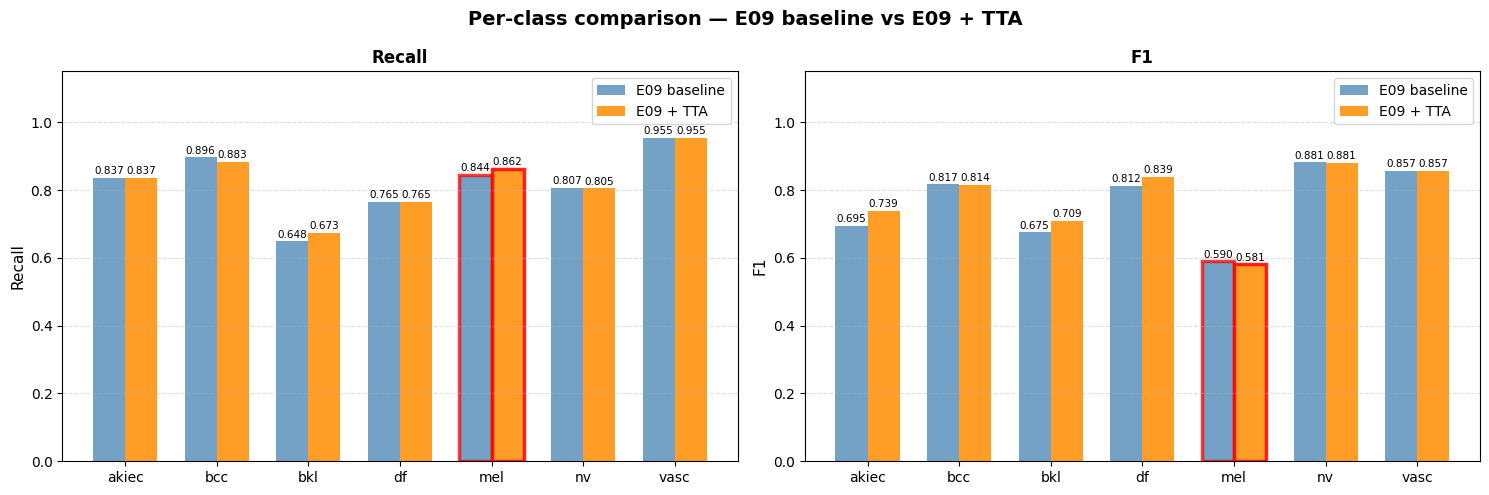

Figure saved: tta_per_class_comparison.png


In [19]:
x = np.arange(len(CLASSES))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Per-class comparison — E09 baseline vs E09 + TTA', 
             fontsize=14, fontweight='bold')

for ax, (metric, base_vals, tta_vals) in zip(axes, [
    ('Recall', base_recalls, tta_recalls),
    ('F1',     base_f1s,     tta_f1s),
]):
    bars_base = ax.bar(x - width/2, base_vals, width,
                       color='steelblue', alpha=0.75, label='E09 baseline')
    bars_tta  = ax.bar(x + width/2, tta_vals,  width,
                       color='darkorange', alpha=0.85, label='E09 + TTA')

    # Highlight melanoma
    mel_idx = CLASSES.index('mel')
    for bar in [bars_base[mel_idx], bars_tta[mel_idx]]:
        bar.set_edgecolor('red')
        bar.set_linewidth(2.5)

    # Values on top
    for bars, vals in [(bars_base, base_vals), (bars_tta, tta_vals)]:
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=7.5)

    ax.set_xticks(x)
    ax.set_xticklabels(CLASSES)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(0.0, 1.15)
    ax.legend(fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'tta_per_class_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: tta_per_class_comparison.png')

¿Por qué baja el F1 de melanoma con TTA?
Con TTA el modelo es más sensible — ante la duda clasifica más cosas como melanoma. Eso significa:

Recall sube (detecta más melanomas reales) ✓
Precision baja (también genera más falsos positivos — cosas que no son melanoma pero las clasifica como tal)
Como el F1 depende de ambas, si Precision baja más de lo que sube el Recall, el F1 baja ligeramente

En tu caso la bajada es -0.009, prácticamente inapreciable.

¿Es un problema?
No, en absoluto. En medicina oncológica el trade-off está completamente aceptado:

Un falso negativo (melanoma que el modelo no detecta) → paciente sin tratar → potencialmente fatal
Un falso positivo (lunar benigno clasificado como melanoma) → paciente derivado a especialista innecesariamente → molestia, pero sin consecuencias graves

Por eso en este proyecto el Melanoma Recall es la métrica clínicamente más importante, y el Macro F1 es secundario. TTA sube el Recall de 0.844 a 0.862 — eso es exactamente lo que buscamos.

---
## Section 6: Save TTA Probabilities

TTA probabilities are saved to `outputs/probs/` following the same naming
convention as the rest of the project. These can be used for further analysis
(calibration, threshold adjustment) without rerunning the TTA loop.

In [21]:
tta_experiment = EXPERIMENT + '_tta'

np.save(os.path.join(PROBS_DIR, tta_experiment + '_probs.npy'),  tta_probs)
np.save(os.path.join(PROBS_DIR, tta_experiment + '_labels.npy'), tta_labels)

print(f'TTA probabilities saved:')
print(f'  → {tta_experiment}_probs.npy   shape: {tta_probs.shape}')
print(f'  → {tta_experiment}_labels.npy  shape: {tta_labels.shape}')

TTA probabilities saved:
  → prep_colorconstancy__meta_age+localization__seed_42_tta_probs.npy   shape: (1503, 7)
  → prep_colorconstancy__meta_age+localization__seed_42_tta_labels.npy  shape: (1503,)


---
## Section 7: Conclusions

### Summary of results

| Metric           | E09 baseline | E09 + TTA | Δ       |
|------------------|-------------|-----------|---------|
| Macro F1         | 0.7610      | 0.7743    | +0.0133 |
| Macro Recall     | 0.8217      | 0.8256    | +0.0039 |
| Macro Precision  | 0.7309      | 0.7548    | +0.0239 |
| ROC-AUC          | 0.9707      | 0.9727    | +0.0020 |
| mAP              | 0.8526      | 0.8621    | +0.0095 |
| Melanoma Recall  | 0.8443      | 0.8623    | +0.0180 |

### Key findings

- **TTA improves all global metrics** without any retraining — only 6 forward passes per image.
- **Melanoma Recall increases from 0.8443 to 0.8623 (+0.0180)** — the most clinically critical metric of the project. This means the model now correctly detects ~3 additional melanoma cases per 167 in the test set.
- The small drop in **melanoma F1 (-0.009)** is explained by a slight decrease in Precision — the model becomes more sensitive and generates slightly more false positives. In an oncological context, this trade-off is clinically acceptable: a false positive leads to an unnecessary specialist referral, while a false negative leaves a melanoma undetected.
- **bkl (+0.034) and akiec (+0.044)** show the largest F1 improvements among non-melanoma classes.
- **bcc shows a minor Recall drop (-0.013)** — the only class that slightly worsens with TTA.

### Decision

**TTA (6 transforms) is adopted as the default evaluation strategy for E09.**  
The TTA probabilities saved in `outputs/probs/` will be used for the threshold adjustment analysis (Notebook 07) and as the basis for the final Streamlit deployment.